In [1]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
path = Path("/Users/thunthita/Lidarforiypnb/LIDar/src/OutputPictCSV/CSVeachday/")

# --------------------------------------------------
# Date extractor (DD-MM-YYYY anywhere in filename)
# --------------------------------------------------
def extract_date_from_filename(fname):
    m = re.search(r"\d{2}-\d{2}-\d{4}", fname)
    if not m:
        return None
    return pd.to_datetime(m.group(), format="%d-%m-%Y")

# --------------------------------------------------
# Select only 19–23 Jan 2026 files
# --------------------------------------------------
files = []
for f in path.glob("*.csv"):
    d = extract_date_from_filename(f.name)
    if d is not None and pd.Timestamp("2026-01-19") <= d <= pd.Timestamp("2026-01-23"):
        files.append((f, d))

files = sorted(files, key=lambda x: x[1])

print("Files to read:")
for f, d in files:
    print(f.name, "->", d.date())

# --------------------------------------------------
# Read + concat
# --------------------------------------------------
dfs = []
for f, d in files:
    df = pd.read_csv(f)
    df["date"] = d
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

# --------------------------------------------------
# Reorder columns: date | range_m | time...
# --------------------------------------------------
df.insert(0, "date", df.pop("date"))
df.insert(1, "range_m", df.pop("range_m"))

print("Final shape:", df.shape)
print("Dates loaded:", df["date"].unique())

Files to read:
19-01-2026.csv -> 2026-01-19
pbls_20-01-2026_0005_0035_to_2335.csv -> 2026-01-20
20-01-2026.csv -> 2026-01-20
21-01-2026.csv -> 2026-01-21
pbls_21-01-2026_0005_0035_to_2335.csv -> 2026-01-21
pbls_22-01-2026_0005_0035_to_2335.csv -> 2026-01-22
22-01-2026.csv -> 2026-01-22
pbls_23-01-2026_0005_0035_to_2335.csv -> 2026-01-23
23-01-2026.csv -> 2026-01-23
Final shape: (10192, 56)
Dates loaded: <DatetimeArray>
['2026-01-19 00:00:00', '2026-01-20 00:00:00', '2026-01-21 00:00:00',
 '2026-01-22 00:00:00', '2026-01-23 00:00:00']
Length: 5, dtype: datetime64[ns]


In [3]:
df

,date,range_m,00.05,00.35,01.05,01.35,02.05,02.35,03.05,03.35,...,22.05,22.35,23.05,23.35,day,timestamp,pbls_km,pbls_m,min_pbls_m,max_pbls_m
0,2026-01-19,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01-19,3.75,0.000077,0.000052,0.000055,0.000050,0.000050,0.000073,0.000064,0.000077,...,0.000066,0.000130,0.000088,0.000048,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-01-19,7.50,0.000652,0.000348,0.000366,0.000319,0.000312,0.000596,0.000479,0.000634,...,0.000507,0.001830,0.000784,0.000288,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-01-19,11.25,0.002469,0.001114,0.001175,0.000978,0.000957,0.002128,0.001619,0.002316,...,0.001852,0.006648,0.002908,0.000843,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-01-19,15.00,0.004405,0.001981,0.002092,0.001740,0.001703,0.003789,0.002881,0.004126,...,0.003303,0.011812,0.005184,0.001499,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10187,2026-01-23,7481.25,-0.238358,-0.304980,-0.256073,-0.244453,-0.051979,-0.098481,-0.236635,-0.088445,...,-0.264256,-0.294186,-0.285680,-0.281731,NaN,NaN,NaN,NaN,NaN,NaN
10188,2026-01-23,7485.00,-0.238597,-0.305286,-0.256330,-0.244699,-0.052031,-0.098580,-0.236872,-0.088534,...,-0.264521,-0.294481,-0.285967,-0.282013,NaN,NaN,NaN,NaN,NaN,NaN
10189,2026-01-23,7488.75,-0.238836,-0.305592,-0.256587,-0.244944,-0.052083,-0.098679,-0.237109,-0.088622,...,-0.264787,-0.294776,-0.286254,-0.282296,NaN,NaN,NaN,NaN,NaN,NaN
10190,2026-01-23,7492.50,-0.239075,-0.305898,-0.256844,-0.245189,-0.052135,-0.098778,-0.237347,-0.088711,...,-0.265052,-0.295072,-0.286540,-0.282579,NaN,NaN,NaN,NaN,NaN,NaN


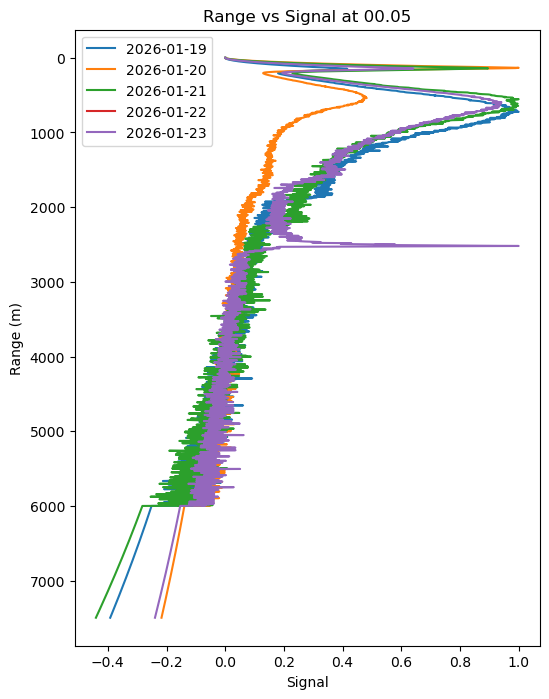


--- 00.05 ---
dtype: float64
NaNs: 2192
min/max: -0.4405849969012303 1.0


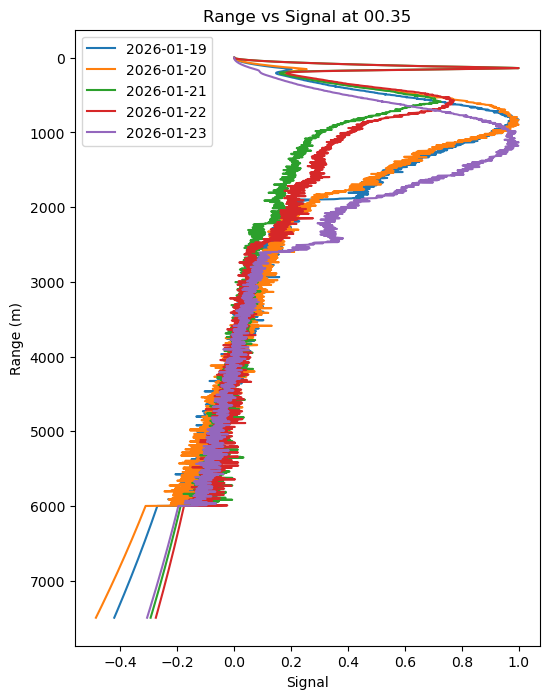


--- 00.35 ---
dtype: float64
NaNs: 192
min/max: -0.486124812876281 1.0


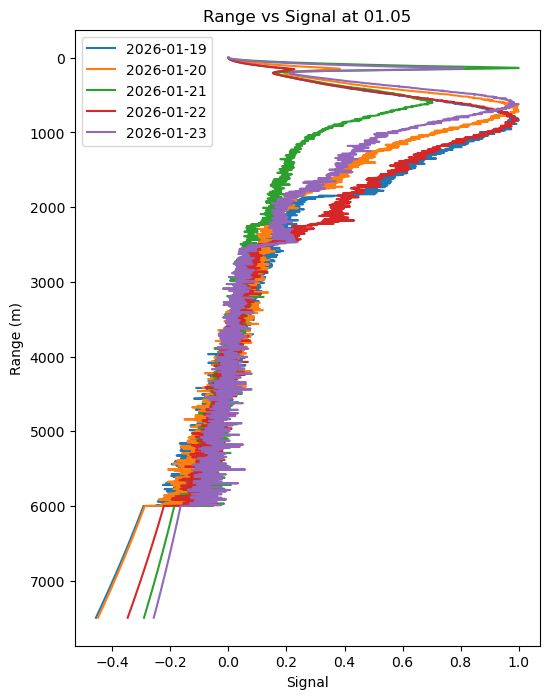


--- 01.05 ---
dtype: float64
NaNs: 192
min/max: -0.4565916955180493 1.0


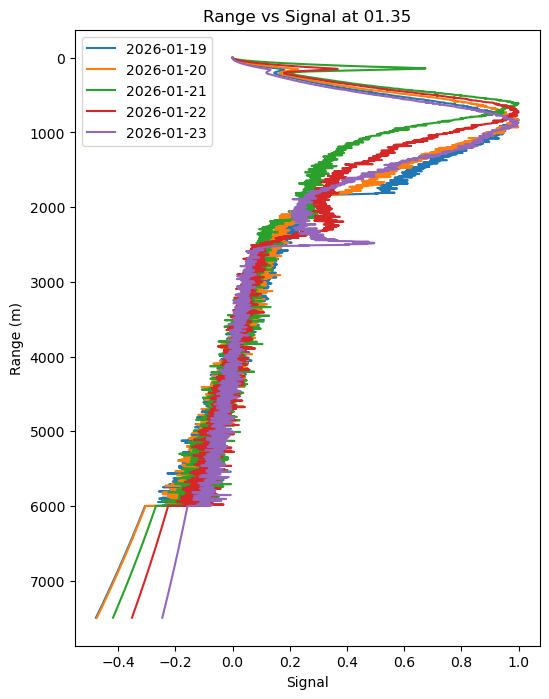


--- 01.35 ---
dtype: float64
NaNs: 192
min/max: -0.4774181913041309 1.0


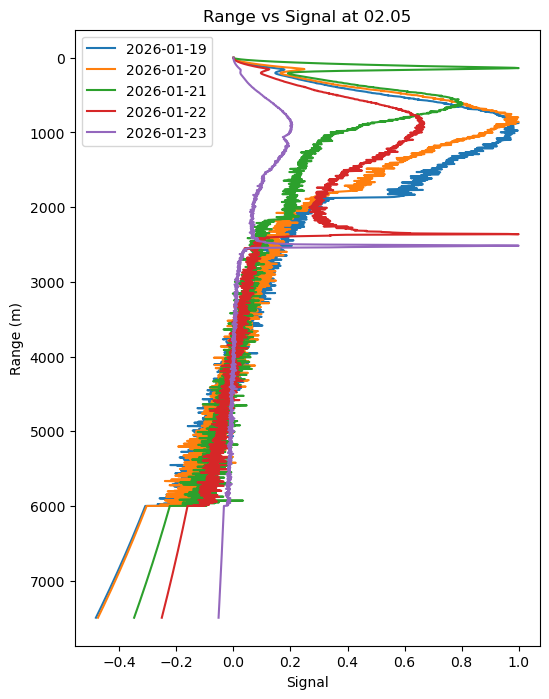


--- 02.05 ---
dtype: float64
NaNs: 192
min/max: -0.4822971955719713 1.0


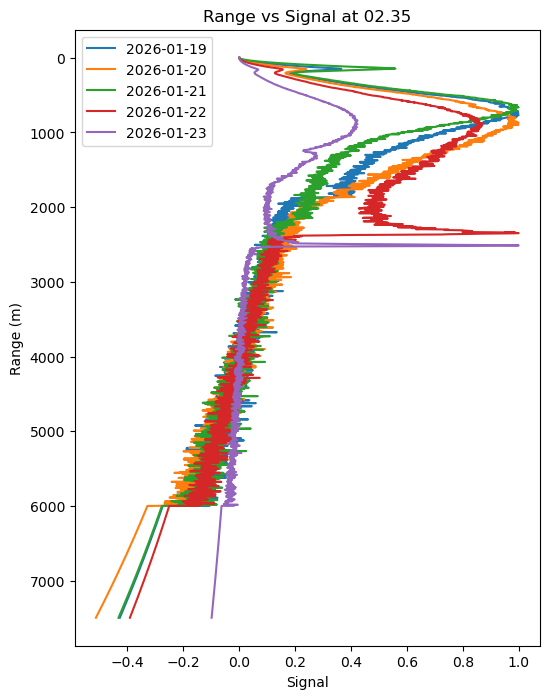


--- 02.35 ---
dtype: float64
NaNs: 192
min/max: -0.5129727555488057 1.0


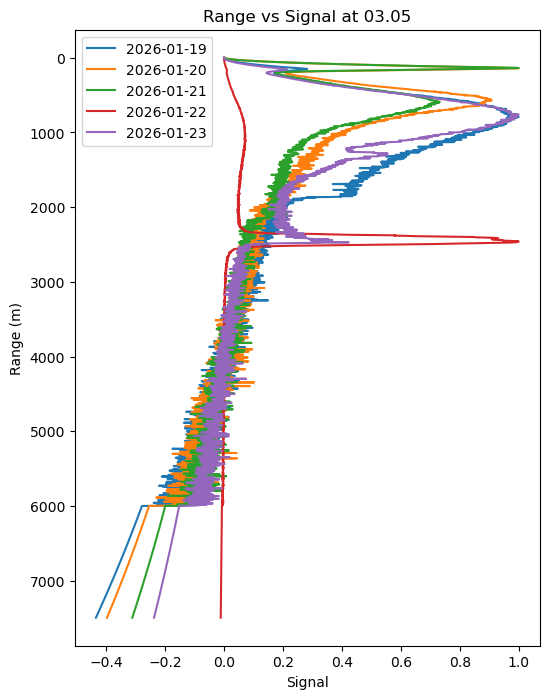


--- 03.05 ---
dtype: float64
NaNs: 192
min/max: -0.4349378140583772 1.0


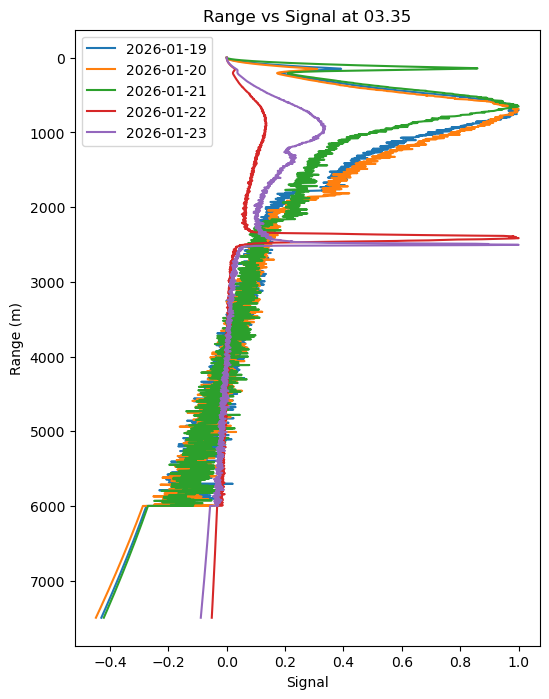


--- 03.35 ---
dtype: float64
NaNs: 192
min/max: -0.4480756436826451 1.0


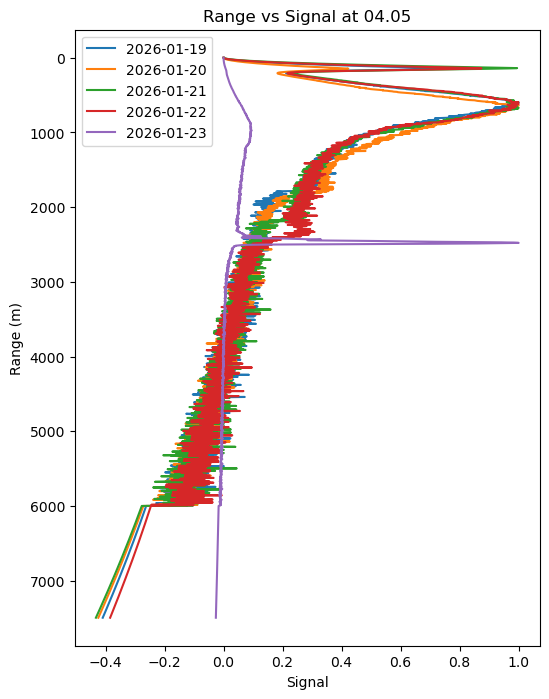


--- 04.05 ---
dtype: float64
NaNs: 192
min/max: -0.4325912036245918 1.0


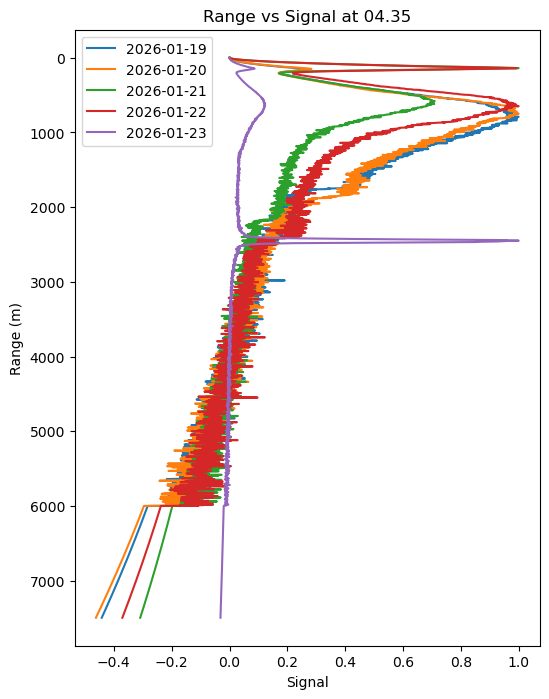


--- 04.35 ---
dtype: float64
NaNs: 192
min/max: -0.4621034709164306 1.0


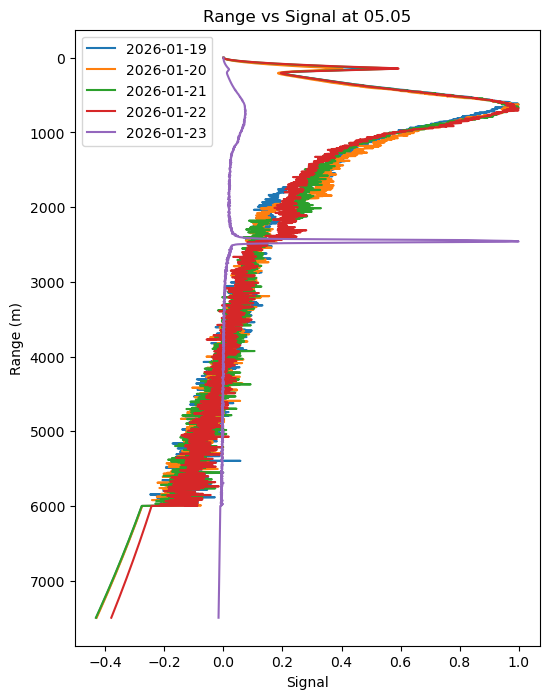


--- 05.05 ---
dtype: float64
NaNs: 192
min/max: -0.4320367785127911 1.0


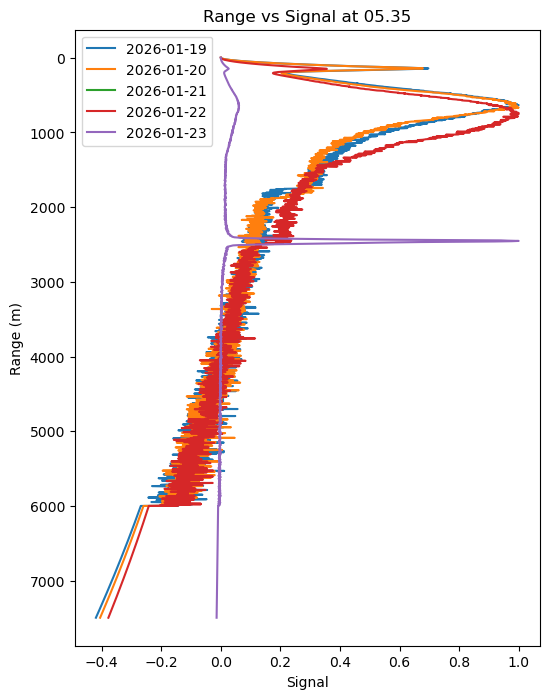


--- 05.35 ---
dtype: float64
NaNs: 2192
min/max: -0.4193912842898102 1.0


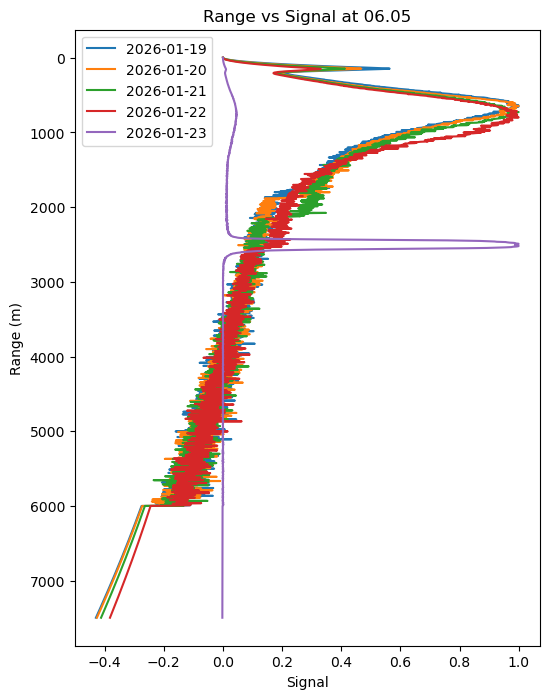


--- 06.05 ---
dtype: float64
NaNs: 192
min/max: -0.4297047099996727 1.0


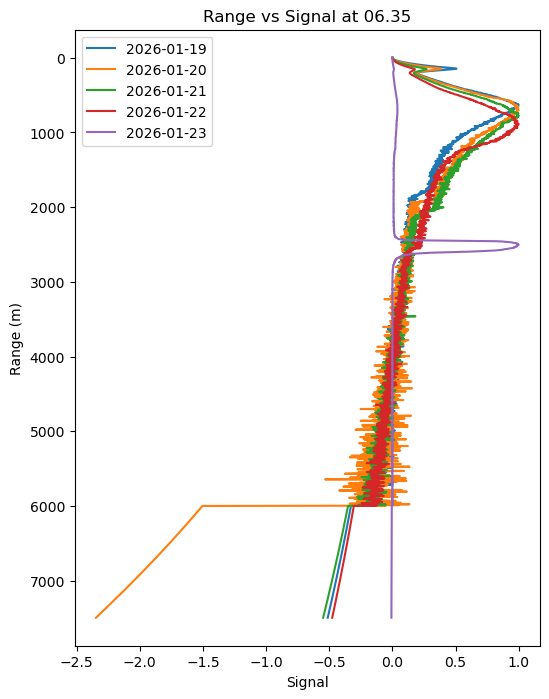


--- 06.35 ---
dtype: float64
NaNs: 192
min/max: -2.3480410527422353 1.0


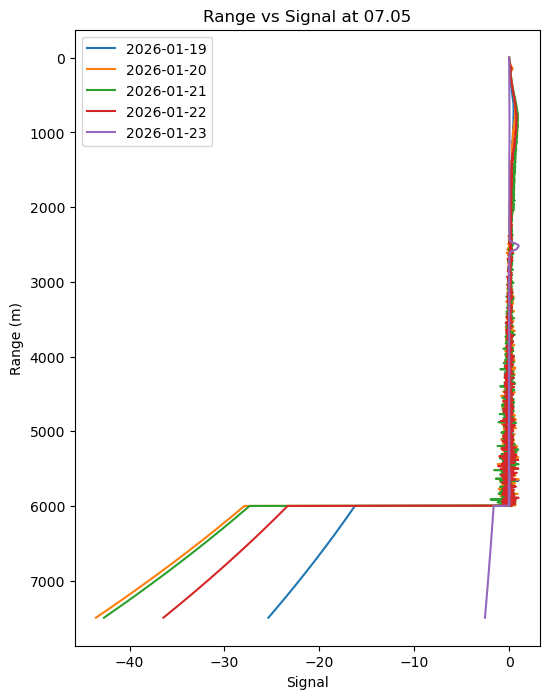


--- 07.05 ---
dtype: float64
NaNs: 192
min/max: -43.54300015682271 1.0


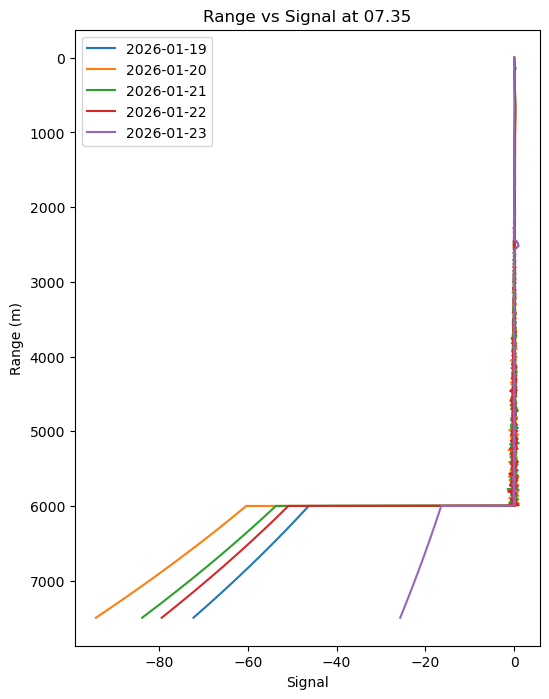


--- 07.35 ---
dtype: float64
NaNs: 192
min/max: -94.21306701640056 1.0


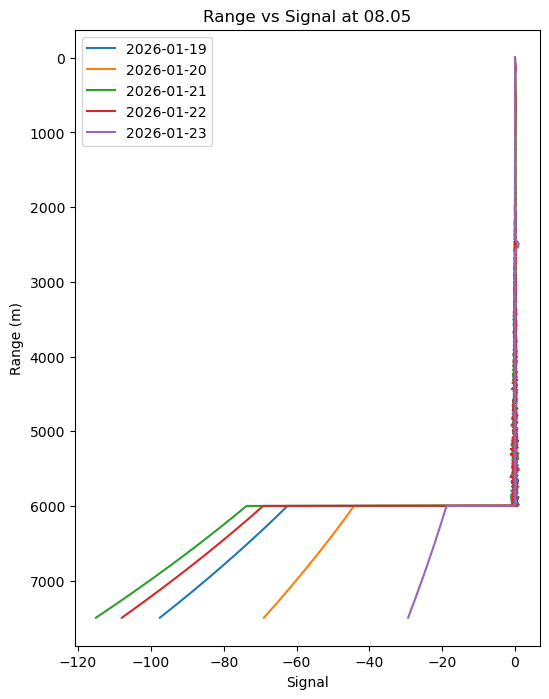


--- 08.05 ---
dtype: float64
NaNs: 192
min/max: -115.10414132139726 1.0


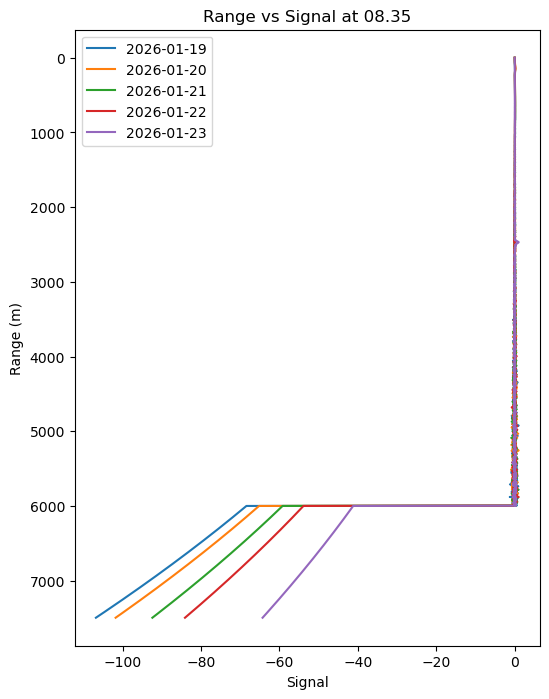


--- 08.35 ---
dtype: float64
NaNs: 192
min/max: -106.81504646372338 1.0


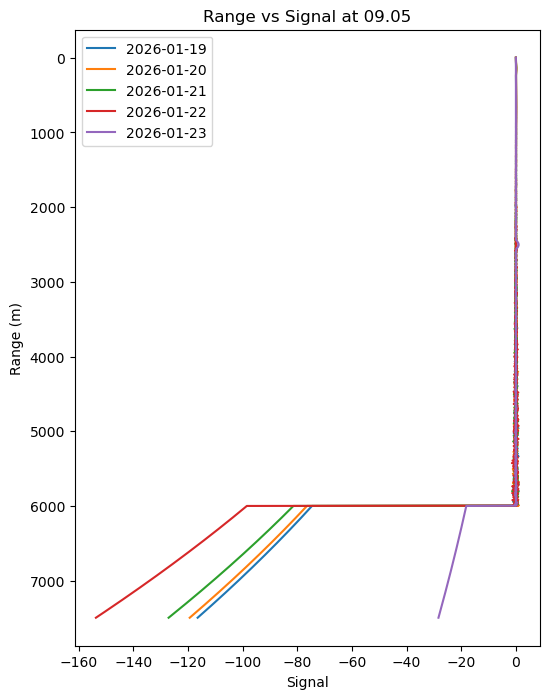


--- 09.05 ---
dtype: float64
NaNs: 192
min/max: -153.63102189976945 1.0


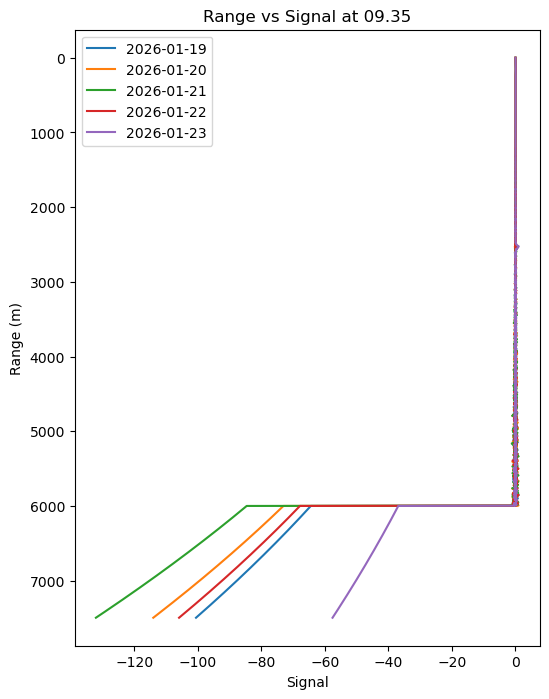


--- 09.35 ---
dtype: float64
NaNs: 192
min/max: -132.03401618473492 1.0


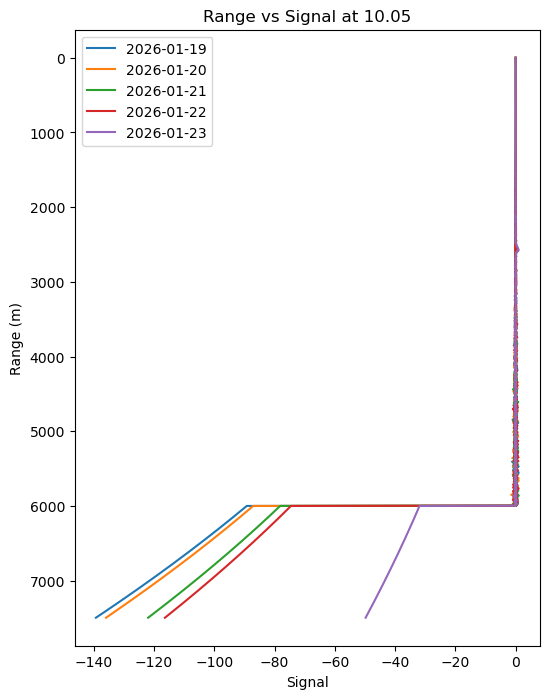


--- 10.05 ---
dtype: float64
NaNs: 192
min/max: -139.27199051531275 1.0


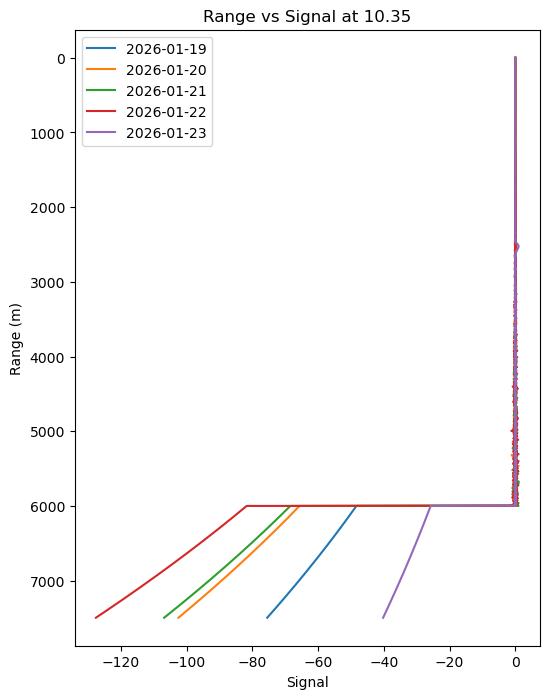


--- 10.35 ---
dtype: float64
NaNs: 192
min/max: -127.59045483876736 1.0


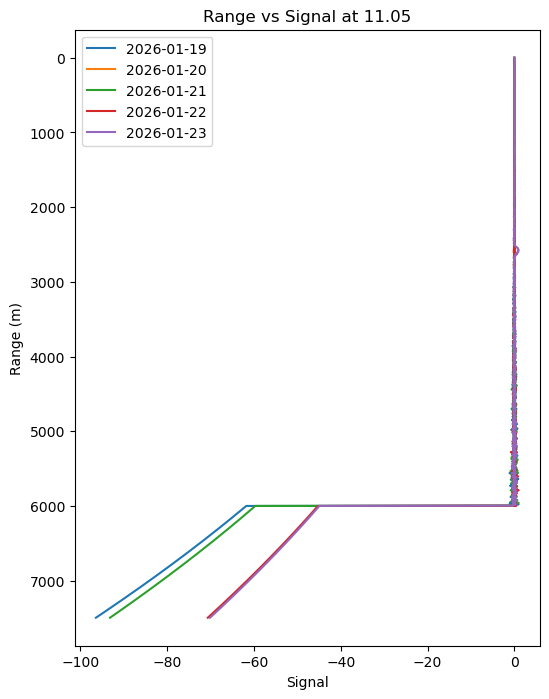


--- 11.05 ---
dtype: float64
NaNs: 2192
min/max: -96.41457223488258 1.0


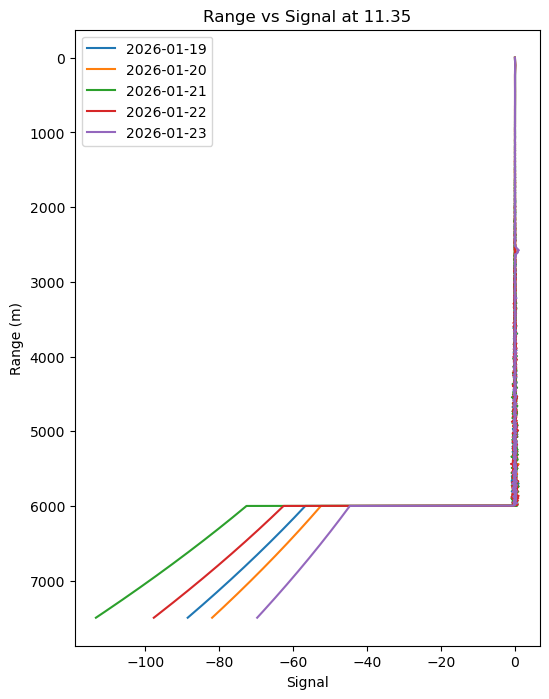


--- 11.35 ---
dtype: float64
NaNs: 192
min/max: -113.41627627989465 1.0


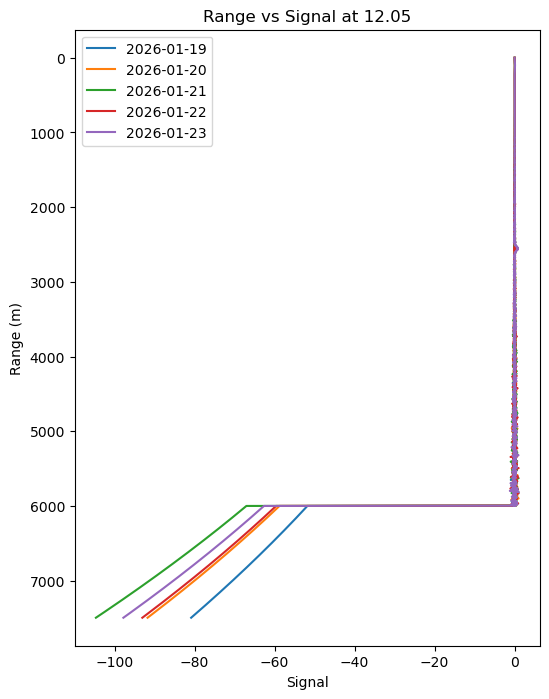


--- 12.05 ---
dtype: float64
NaNs: 192
min/max: -104.68062652782466 1.0


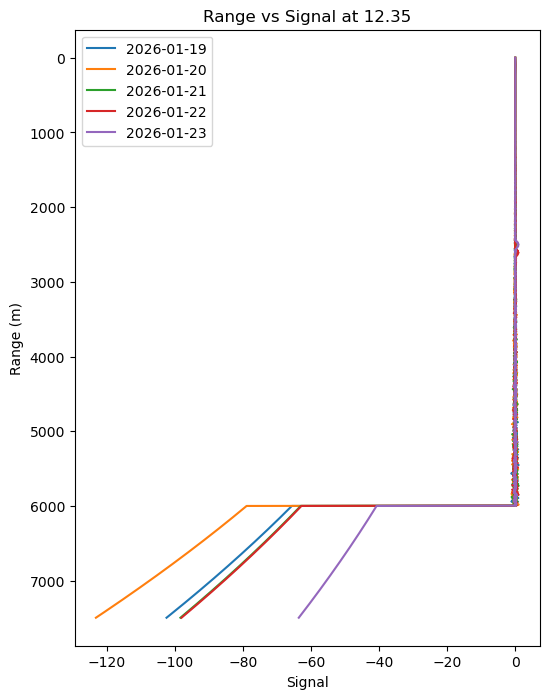


--- 12.35 ---
dtype: float64
NaNs: 192
min/max: -123.1935390153056 1.0


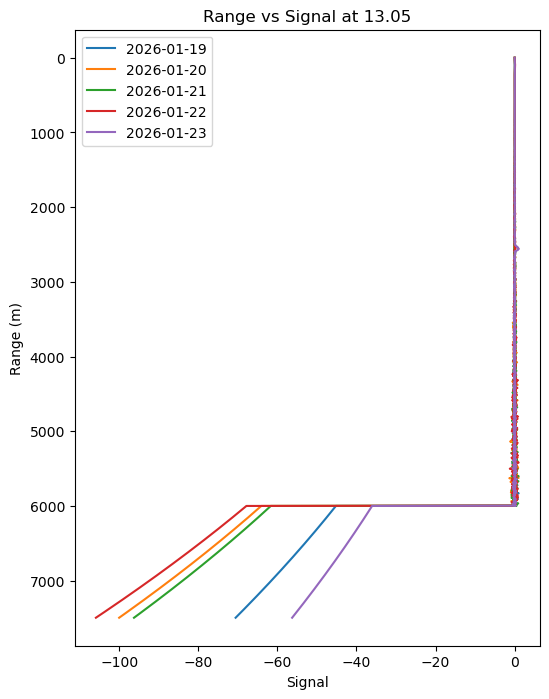


--- 13.05 ---
dtype: float64
NaNs: 192
min/max: -105.89079989186968 1.0


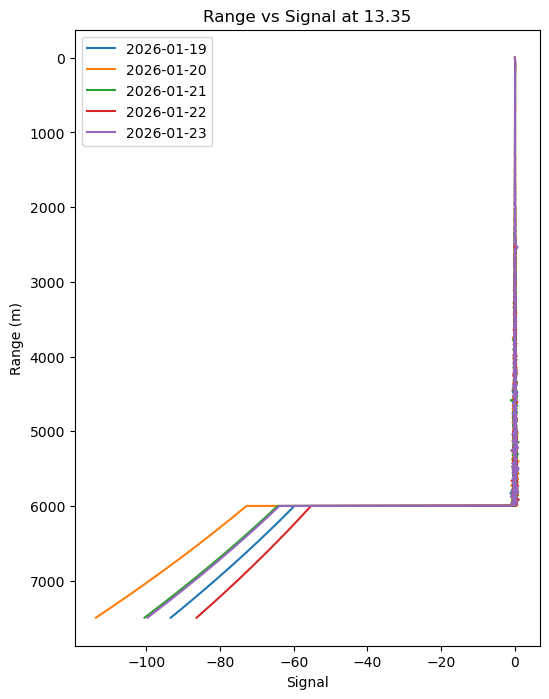


--- 13.35 ---
dtype: float64
NaNs: 192
min/max: -113.646386722849 1.0


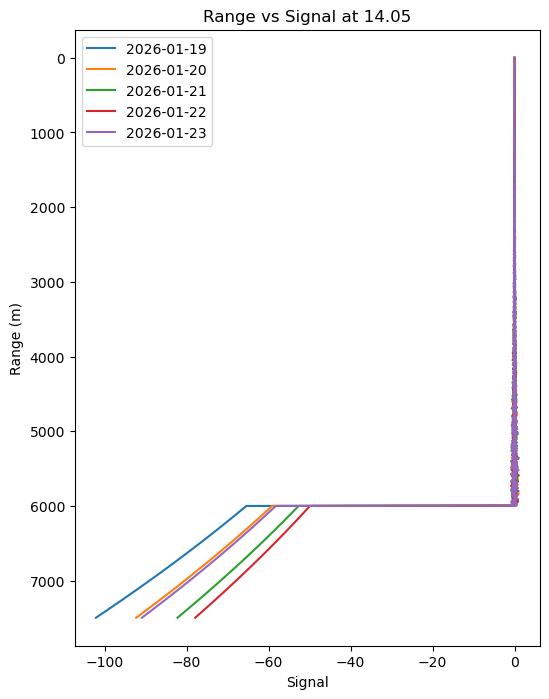


--- 14.05 ---
dtype: float64
NaNs: 192
min/max: -102.09977188168656 1.0


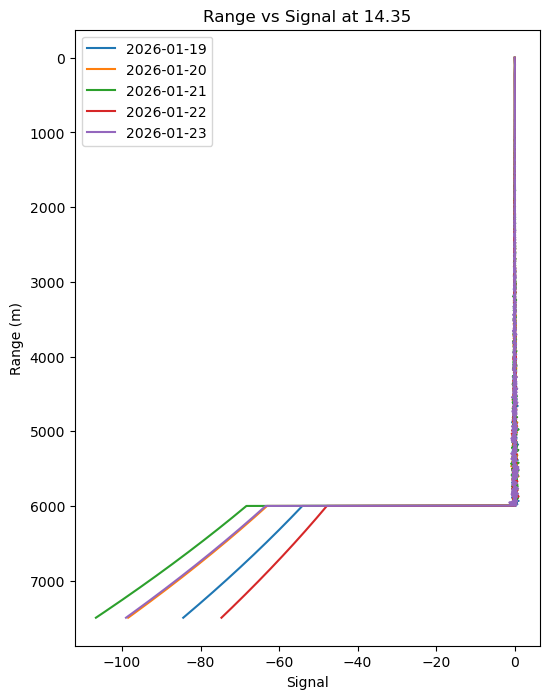


--- 14.35 ---
dtype: float64
NaNs: 192
min/max: -106.66625421208904 1.0


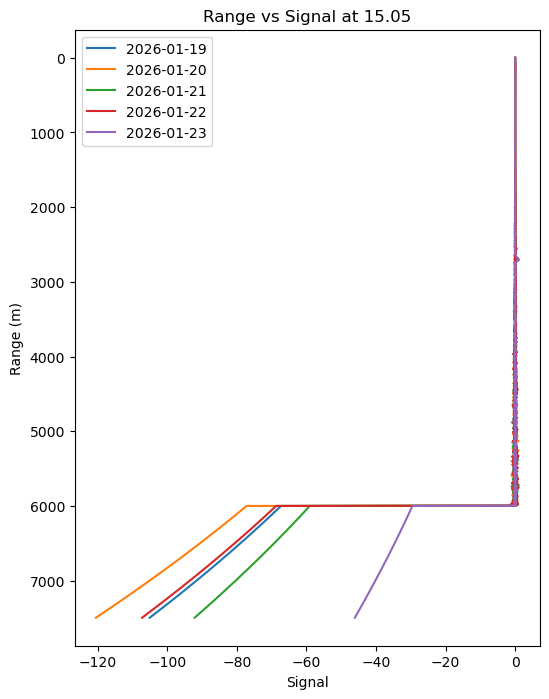


--- 15.05 ---
dtype: float64
NaNs: 192
min/max: -120.4691140284124 1.0


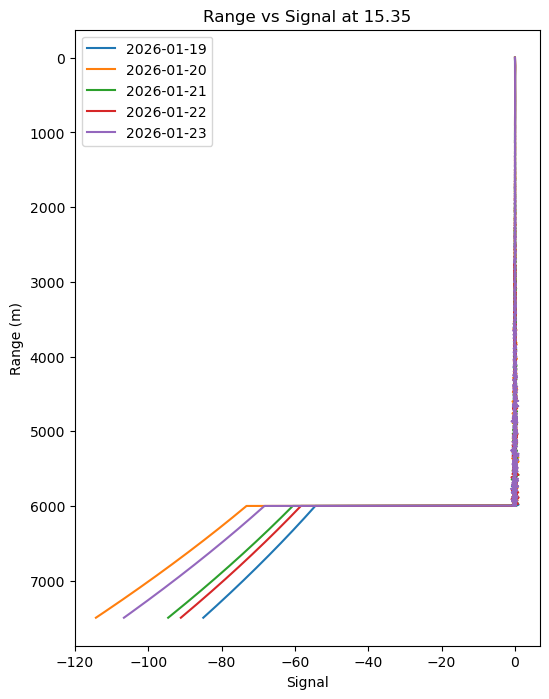


--- 15.35 ---
dtype: float64
NaNs: 192
min/max: -114.28004449634112 1.0


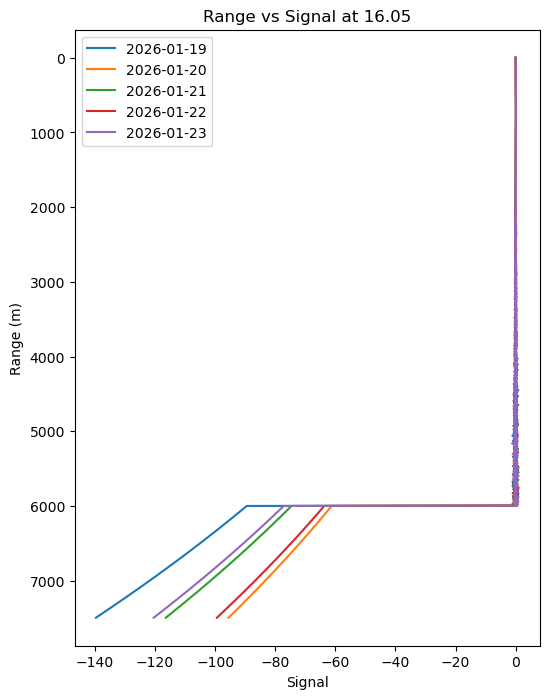


--- 16.05 ---
dtype: float64
NaNs: 192
min/max: -139.701773508932 1.0


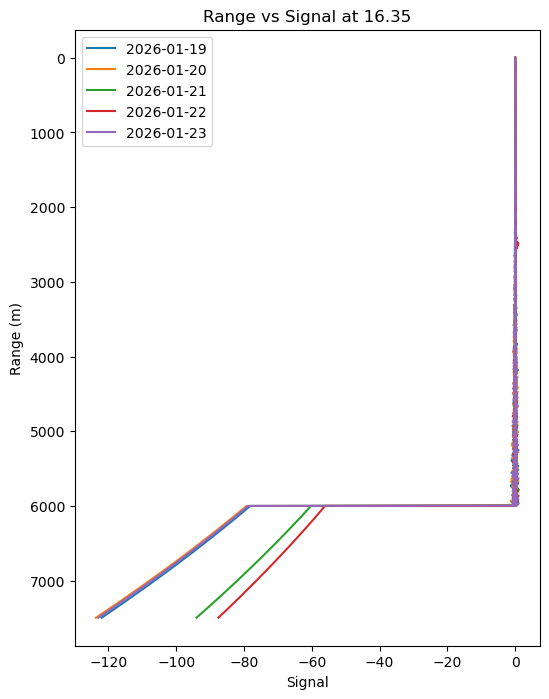


--- 16.35 ---
dtype: float64
NaNs: 192
min/max: -123.67454934348466 1.0


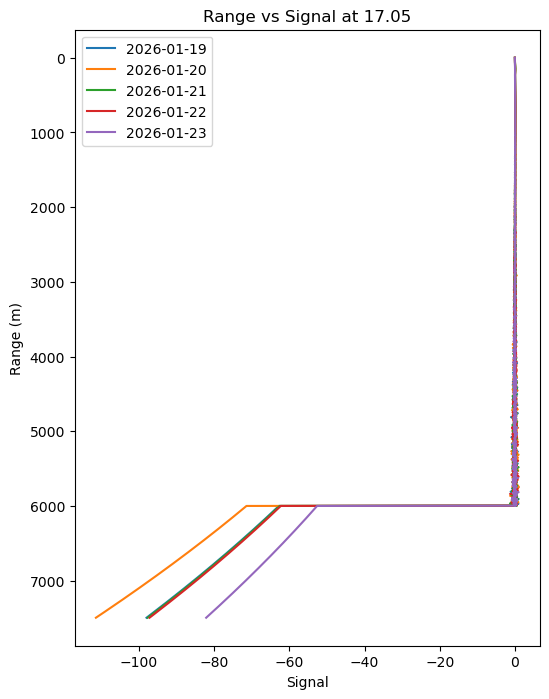


--- 17.05 ---
dtype: float64
NaNs: 192
min/max: -111.48518991639132 1.0


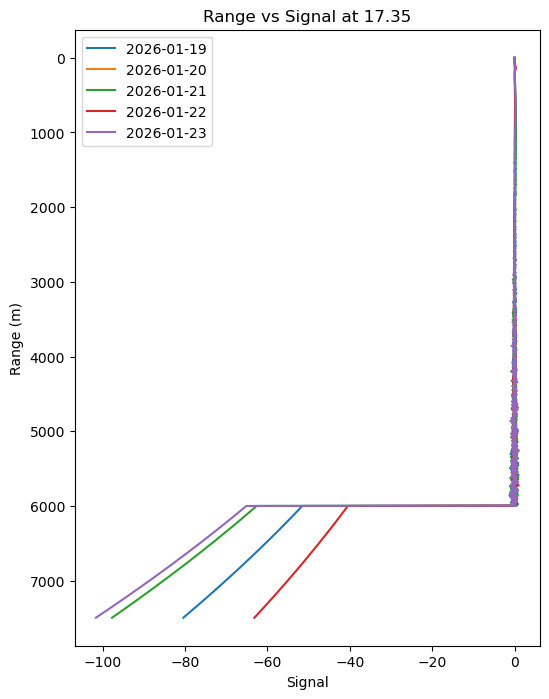


--- 17.35 ---
dtype: float64
NaNs: 2192
min/max: -101.6209356400046 1.0


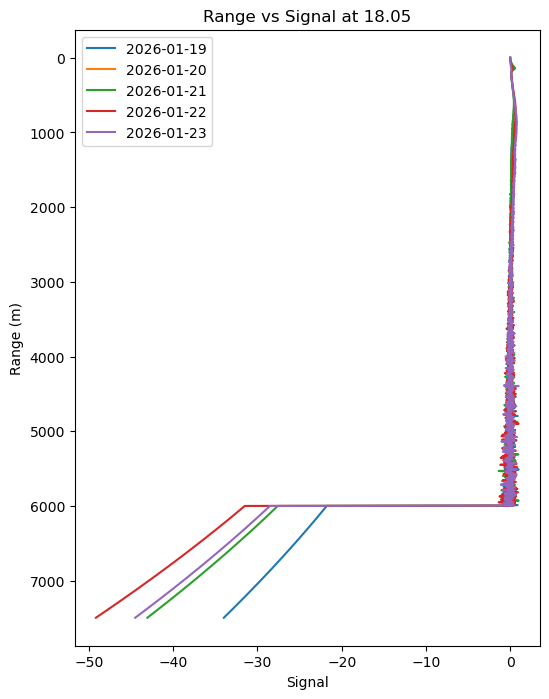


--- 18.05 ---
dtype: float64
NaNs: 2192
min/max: -49.16858418843028 1.0


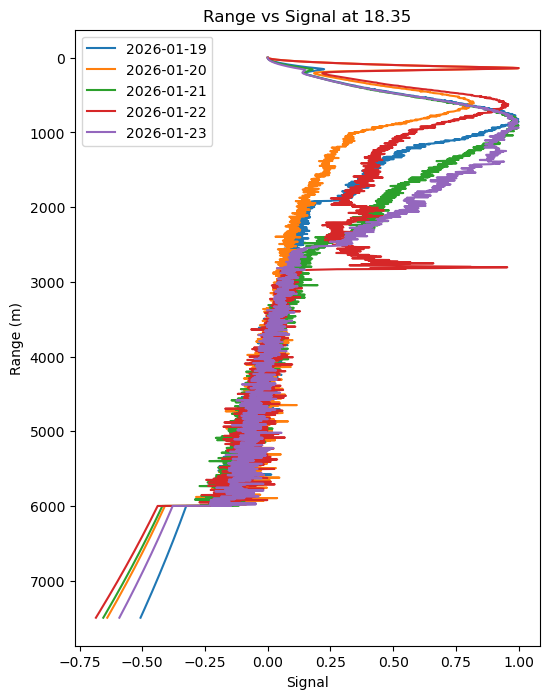


--- 18.35 ---
dtype: float64
NaNs: 192
min/max: -0.6846209763247119 1.0


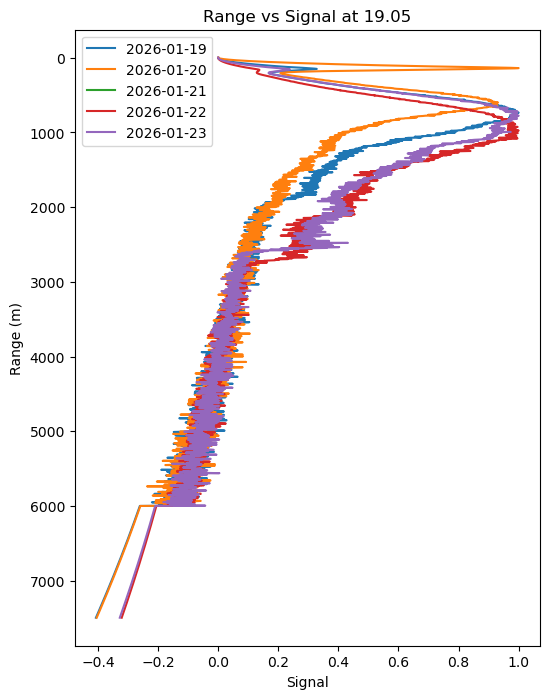


--- 19.05 ---
dtype: float64
NaNs: 2192
min/max: -0.4069436603050182 1.0


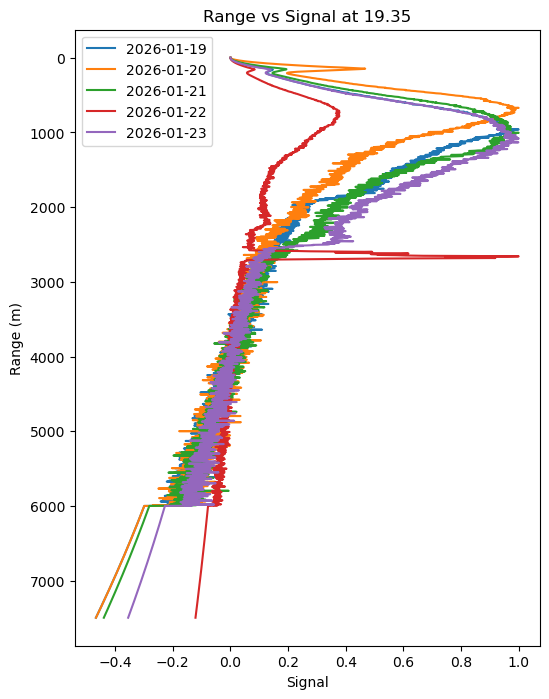


--- 19.35 ---
dtype: float64
NaNs: 192
min/max: -0.4667639294178114 1.0


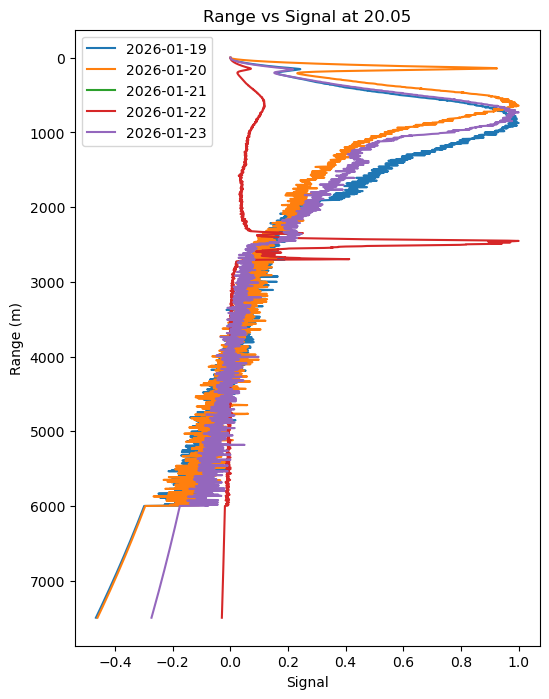


--- 20.05 ---
dtype: float64
NaNs: 2192
min/max: -0.4664715582625877 1.0


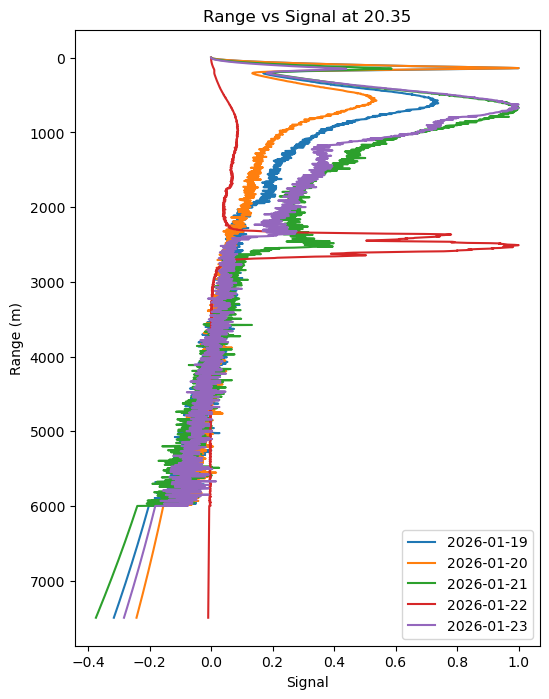


--- 20.35 ---
dtype: float64
NaNs: 192
min/max: -0.3744055078790372 1.0


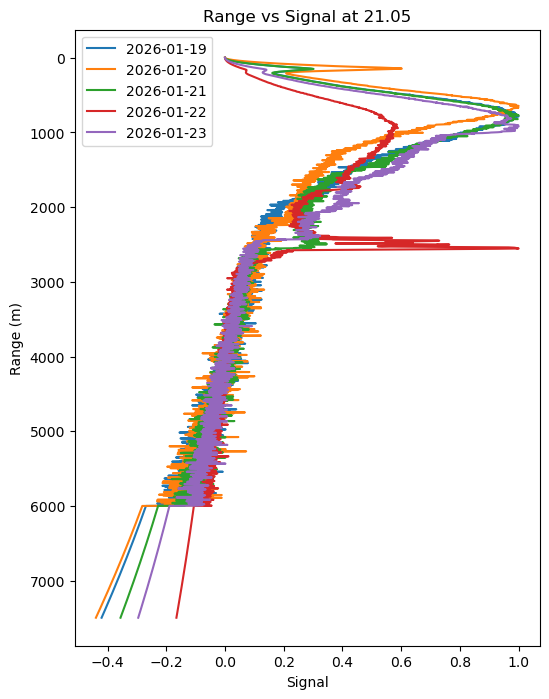


--- 21.05 ---
dtype: float64
NaNs: 192
min/max: -0.439675416343197 1.0


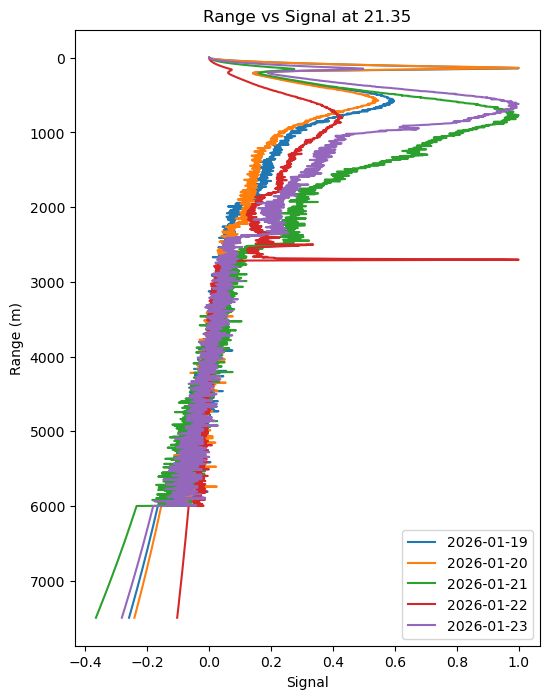


--- 21.35 ---
dtype: float64
NaNs: 192
min/max: -0.3658462793847155 1.0


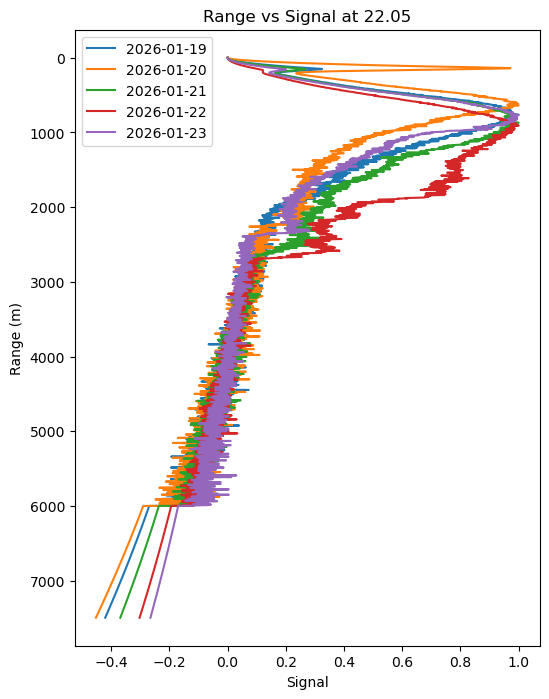


--- 22.05 ---
dtype: float64
NaNs: 192
min/max: -0.4526783967676961 1.0


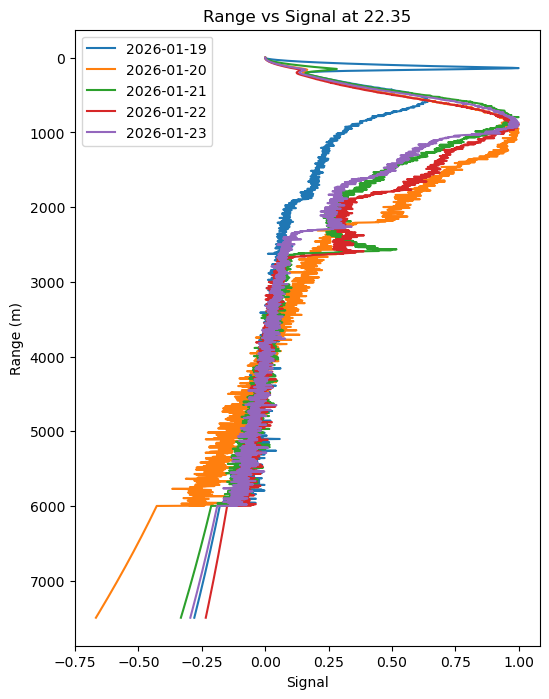


--- 22.35 ---
dtype: float64
NaNs: 192
min/max: -0.6678277643940577 1.0


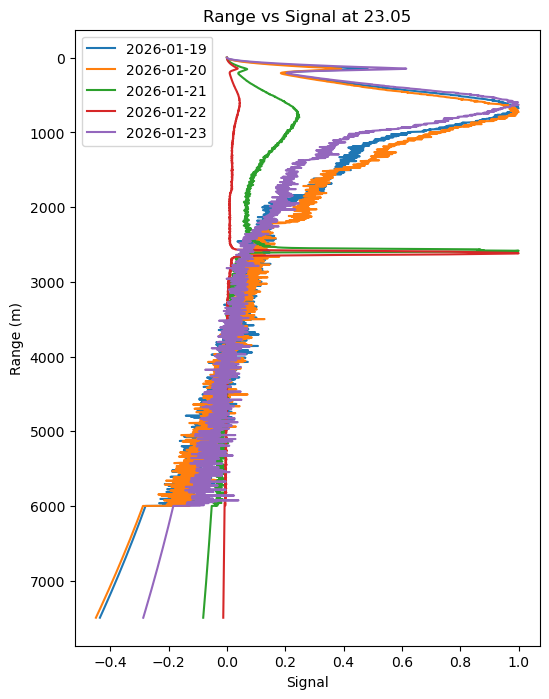


--- 23.05 ---
dtype: float64
NaNs: 192
min/max: -0.4491076745824485 1.0


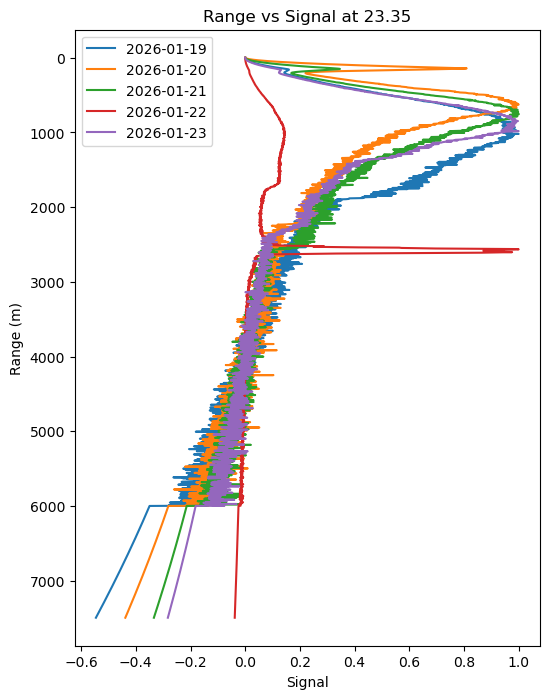


--- 23.35 ---
dtype: float64
NaNs: 192
min/max: -0.5459335916498634 1.0


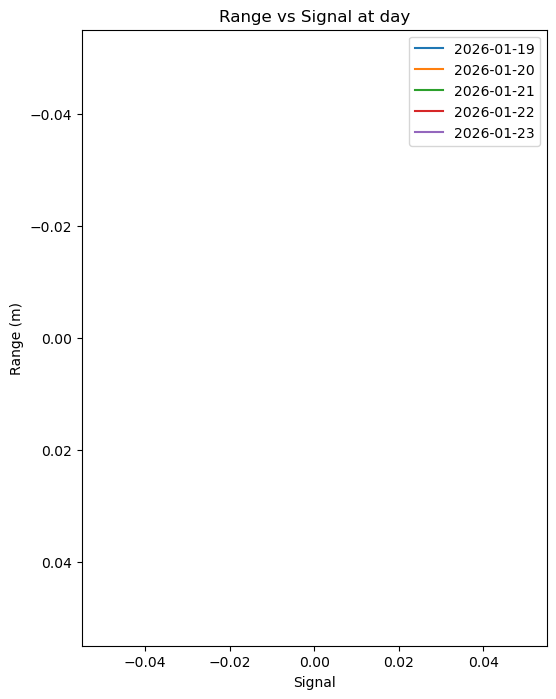


--- day ---
dtype: float64
NaNs: 10192
min/max: nan nan


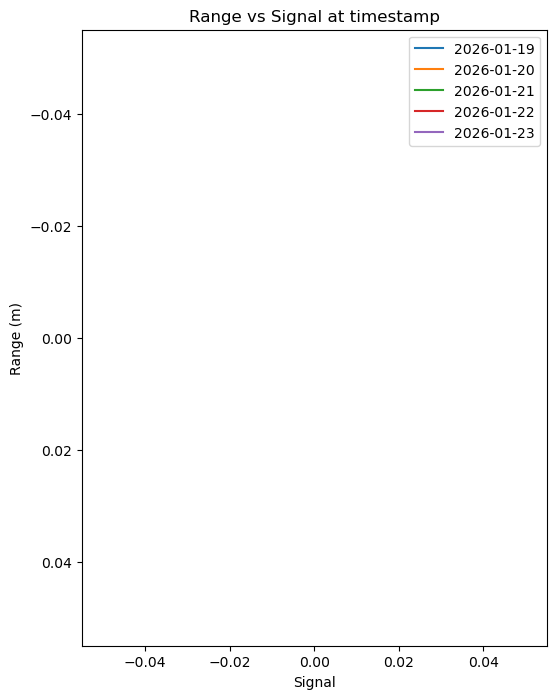


--- timestamp ---
dtype: float64
NaNs: 10192
min/max: nan nan


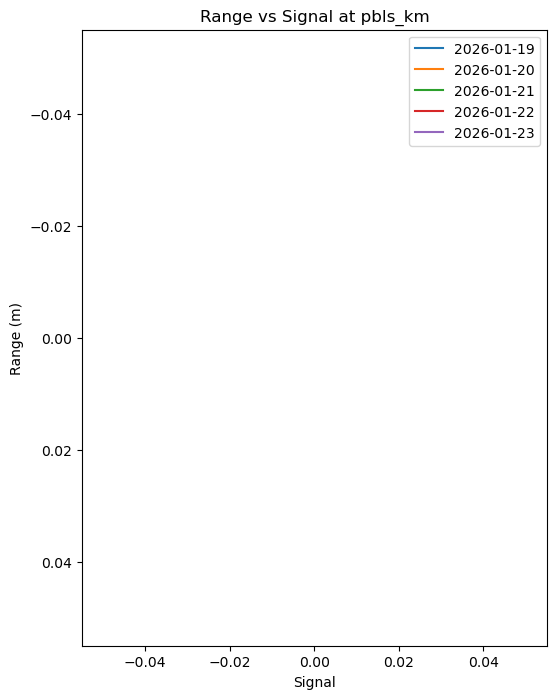


--- pbls_km ---
dtype: float64
NaNs: 10000
min/max: 1.2591283 2.78807


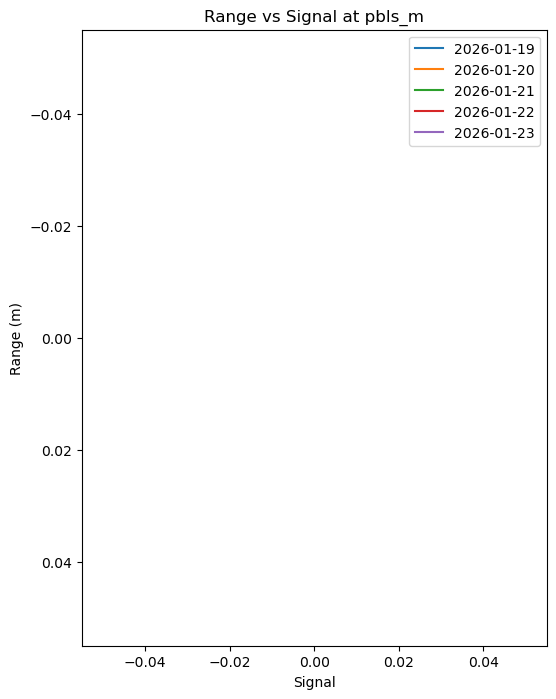


--- pbls_m ---
dtype: float64
NaNs: 10000
min/max: 1259.1283 2788.0699999999997


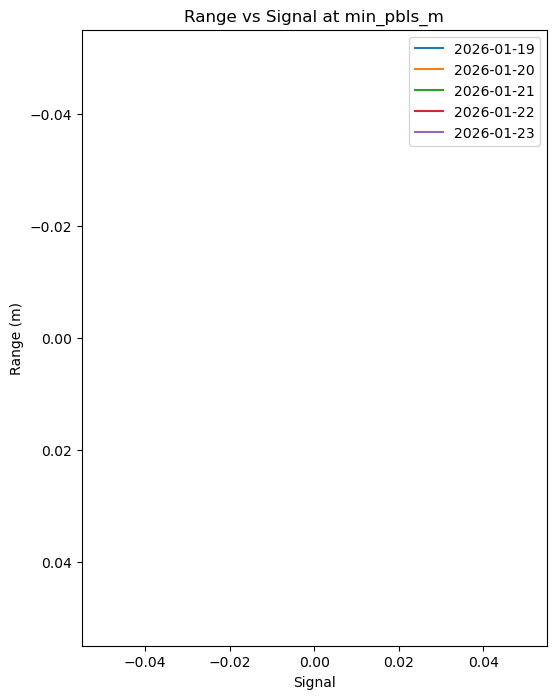


--- min_pbls_m ---
dtype: float64
NaNs: 10000
min/max: 959.1283 2488.0699999999997


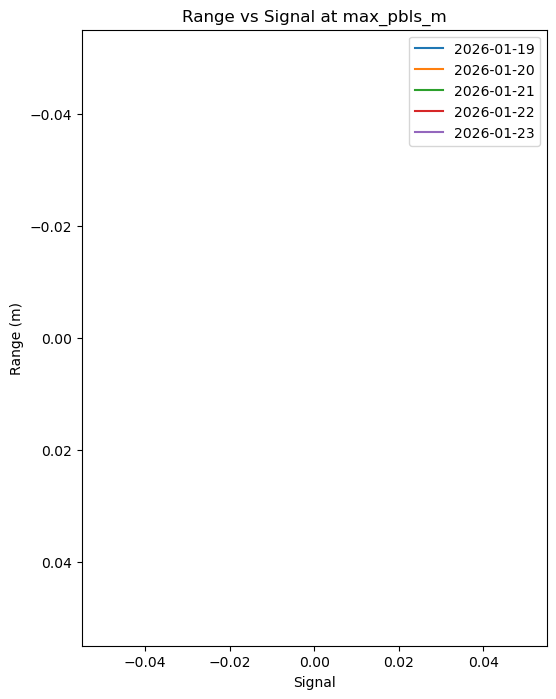


--- max_pbls_m ---
dtype: float64
NaNs: 10000
min/max: 1559.1283 3088.0699999999997


In [4]:
# --- make sure date is datetime ---
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# --- select date range (inclusive) ---
mask = df["date"].between("2026-01-19", "2026-01-23", inclusive="both")
df_sel = df.loc[mask].copy()

# --- find time columns (everything except date, range_m) ---
time_cols = [c for c in df_sel.columns if c not in ("date", "range_m")]

# --- make sure range is numeric ---
df_sel["range_m"] = pd.to_numeric(df_sel["range_m"], errors="coerce")

for t in time_cols:
    # ensure signal is numeric
    df_sel[t] = pd.to_numeric(df_sel[t], errors="coerce")

    fig, ax = plt.subplots(figsize=(6, 8), clear=True)

    for d, g in df_sel.groupby("date"):
        gg = g.dropna(subset=[t, "range_m"])
        ax.plot(
            gg[t].to_numpy(dtype=float),
            gg["range_m"].to_numpy(dtype=float),
            label=d.strftime("%Y-%m-%d"),
        )

    ax.invert_yaxis()
    ax.set_xlabel("Signal")          # "Range Square" sounded mismatched
    ax.set_ylabel("Range (m)")
    ax.set_title(f"Range vs Signal at {t}")
    ax.legend()
    plt.show()

    # --- correct debug for numeric data ---
    print("\n---", t, "---")
    print("dtype:", df_sel[t].dtype)
    print("NaNs:", int(df_sel[t].isna().sum()))
    print("min/max:", df_sel[t].min(), df_sel[t].max())


In [5]:
import re
import pandas as pd

# 1) เลือกเฉพาะคอลัมน์เวลาแบบ 00.05, 23.35
time_cols = [c for c in df_sel.columns if re.fullmatch(r"\d{1,2}\.\d{2}", str(c))]

print("n_time_cols =", len(time_cols))
print("example:", time_cols[:10])

# 2) melt เฉพาะเวลา
df_long = df_sel.melt(
    id_vars=["date", "range_m"],
    value_vars=time_cols,
    var_name="time",
    value_name="signal"
)

# 3) สร้าง datetime
df_long["time_str"] = df_long["time"].astype(str).str.replace(".", ":", regex=False)

df_long["datetime"] = pd.to_datetime(
    df_long["date"].dt.strftime("%Y-%m-%d") + " " + df_long["time_str"],
    format="%Y-%m-%d %H:%M"
)


n_time_cols = 48
example: ['00.05', '00.35', '01.05', '01.35', '02.05', '02.35', '03.05', '03.35', '04.05', '04.35']


In [6]:
dup = df_long.duplicated(subset=["range_m", "datetime"], keep=False)
print("n duplicated rows:", dup.sum())

print(df_long.loc[dup, ["date","time","datetime","range_m","signal"]]
      .sort_values(["datetime","range_m"])
      .head(30))


n duplicated rows: 9216
           date   time            datetime  range_m  signal
2000 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2001 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2002 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2003 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2004 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2005 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2006 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2007 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2008 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2009 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2010 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2011 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2012 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2013 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2014 2026-01-20  00.05 2026-01-20 00:05:00      NaN     NaN
2015 2026-01-20 

Series([], Name: count, dtype: int64)


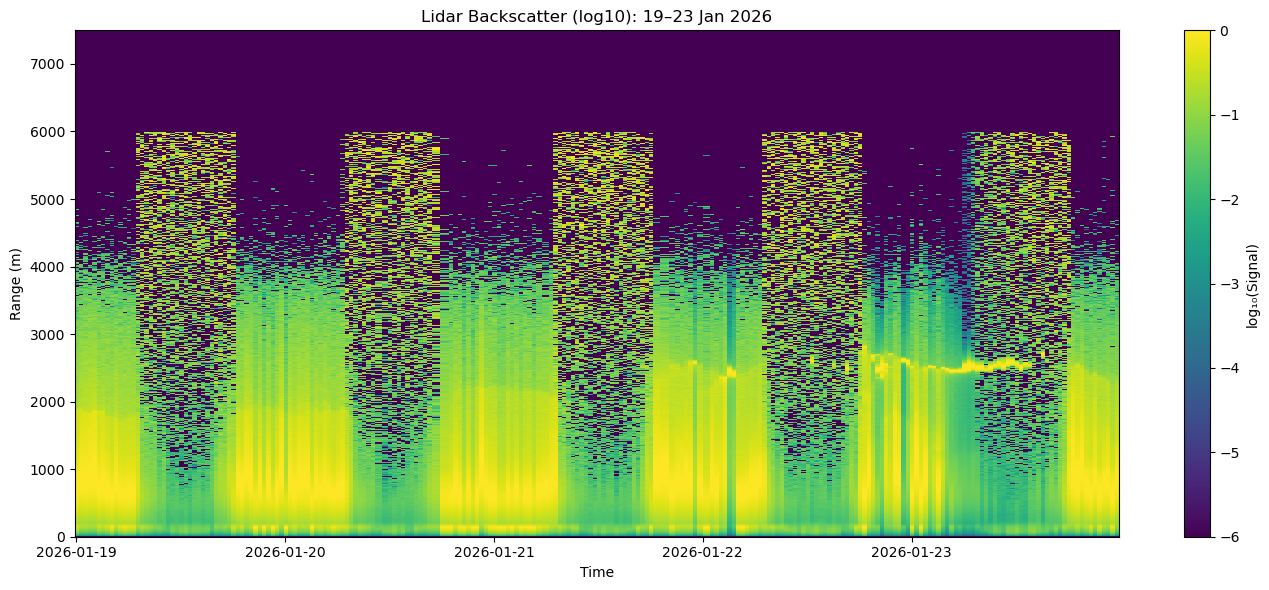

In [7]:
import numpy as np
# 3) Filter date range
# --------------------------------------------------
# df_sel = df[
#     (df["date"] >= "2026-01-19") &
#     (df["date"] <= "2026-01-30")
# ]

# --------------------------------------------------
# 4) Wide → long format
# --------------------------------------------------
time_cols = [c for c in df_sel.columns if re.fullmatch(r"\d{1,2}\.\d{2}", str(c))]

df_long = df_sel.melt(
    id_vars=["date", "range_m"],
    value_vars=time_cols,      # ✅ เพิ่มบรรทัดนี้
    var_name="time",
    value_name="signal"
)
bad_time = df_long.loc[~df_long["time"].astype(str).str.match(r"^\d{1,2}\.\d{2}$"), "time"]
print(bad_time.value_counts().head(30))

# --------------------------------------------------
# 5) Build datetime (date + HH.MM)
# --------------------------------------------------
df_long["datetime"] = pd.to_datetime(
    df_long["date"].dt.strftime("%Y-%m-%d") + " " +
    df_long["time"].str.replace(".", ":", regex=False),
    format="%Y-%m-%d %H:%M"
)

# --------------------------------------------------
# 6) Pivot to 2D grid (range × time)
# --------------------------------------------------
# ลบทิ้งแถวที่ range_m หรือ signal เป็น NaN
df_long = df_long.dropna(subset=["range_m", "signal"])

Z = df_long.pivot(
    index="range_m",
    columns="datetime",
    values="signal"
).sort_index()


# Optional: limit range (e.g. PBL-focused)
# Z = Z.loc[Z.index <= 3000]

# --------------------------------------------------
# 7) LOG-scale color plot (lidar curtain)
# --------------------------------------------------
Z_log = np.log10(Z.clip(lower=1e-6))  # avoid log(0)

plt.figure(figsize=(14, 6))

pcm = plt.pcolormesh(
    Z_log.columns,
    Z_log.index,
    Z_log.values,
    shading="auto",
    cmap="viridis"
)

# plt.gca().invert_yaxis()
plt.xlabel("Time")
plt.ylabel("Range (m)")
plt.title("Lidar Backscatter (log10): 19–23 Jan 2026")
plt.colorbar(pcm, label="log₁₀(Signal)")

plt.tight_layout()
plt.show()


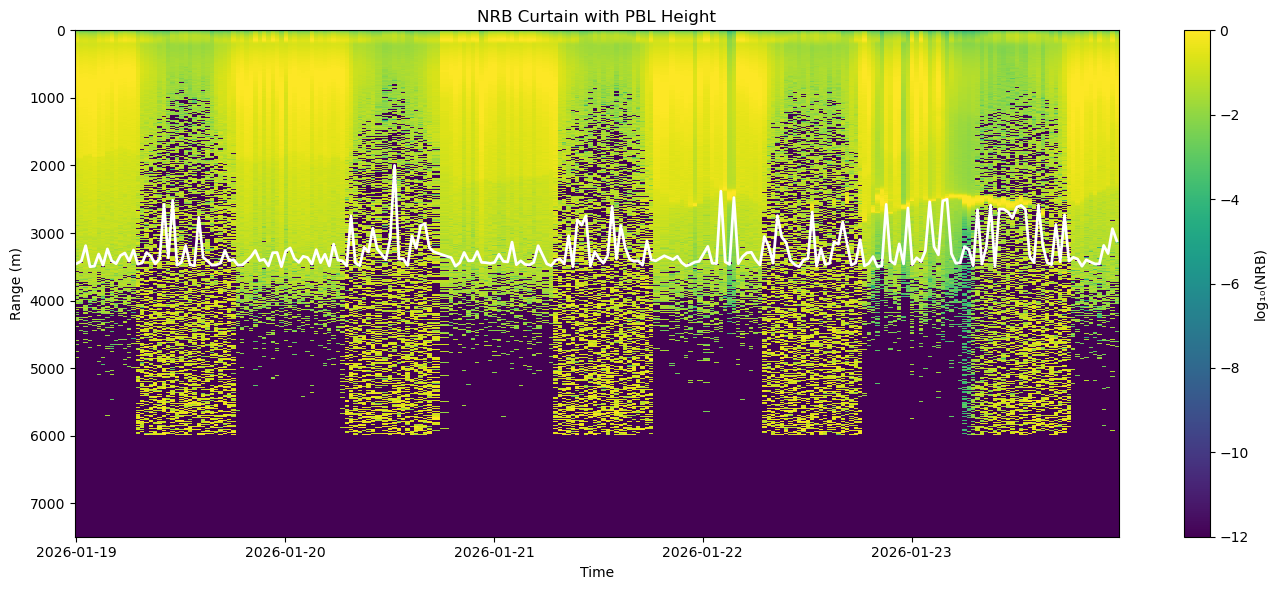

In [8]:
def smooth_1d(x, win=11):
    """Simple moving average smoothing (odd win recommended)."""
    x = np.asarray(x, float)
    if win <= 1:
        return x
    win = int(win)
    if win % 2 == 0:
        win += 1
    k = np.ones(win) / win
    # pad edges to avoid shrink
    xp = np.pad(x, (win//2, win//2), mode="edge")
    return np.convolve(xp, k, mode="valid")

def pbl_from_profile_gradient(range_m, nrb, zmin=100, zmax=3500, smooth_win=11):
    """
    Estimate PBL height from a single NRB profile using max negative gradient of log10(NRB).
    Returns pbl_m (float) or np.nan if not found.
    """
    z = np.asarray(range_m, float)
    s = np.asarray(nrb, float)

    # mask valid finite points
    good = np.isfinite(z) & np.isfinite(s)
    z, s = z[good], s[good]
    if len(z) < 10:
        return np.nan

    # focus on plausible PBL search window
    m = (z >= zmin) & (z <= zmax)
    z2, s2 = z[m], s[m]
    if len(z2) < 10:
        return np.nan

    # avoid log(<=0)
    s2 = np.clip(s2, 1e-12, None)
    # log + smooth
    y = np.log10(s2)
    y_s = smooth_1d(y, win=smooth_win)

    # gradient dy/dz (use np.gradient for uneven spacing safety)
    dy_dz = np.gradient(y_s, z2)

    # PBL top = strongest negative gradient
    idx = np.argmin(dy_dz)
    return float(z2[idx])

def pbl_timeseries_from_curtain(Z, zmin=100, zmax=3500, smooth_win=11):
    """
    Z: DataFrame indexed by range_m, columns are datetimes, values are NRB/signal.
    Returns DataFrame with columns ['datetime','pbl_m'].
    """
    z = Z.index.values
    out = []
    for t in Z.columns:
        prof = Z[t].values
        pbl = pbl_from_profile_gradient(z, prof, zmin=zmin, zmax=zmax, smooth_win=smooth_win)
        out.append((t, pbl))
    return pd.DataFrame(out, columns=["datetime", "pbl_m"])

# --------------------------
# Example usage (assuming you already built Z from your selected dates)
# --------------------------
# PBL series
pbl_df = pbl_timeseries_from_curtain(Z, zmin=100, zmax=3500, smooth_win=11)

# Plot PBL over your curtain (log scale)
Z_log = np.log10(Z.clip(lower=1e-12))

fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")
ax.set_facecolor("white")

pcm = ax.pcolormesh(
    Z_log.columns,
    Z_log.index,
    Z_log.values,
    shading="auto",
    cmap="viridis"
)

ax.invert_yaxis()
ax.plot(pbl_df["datetime"], pbl_df["pbl_m"], color="white", linewidth=2)

ax.set_xlabel("Time")
ax.set_ylabel("Range (m)")
ax.set_title("NRB Curtain with PBL Height")

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("log₁₀(NRB)")

plt.tight_layout()
plt.show()


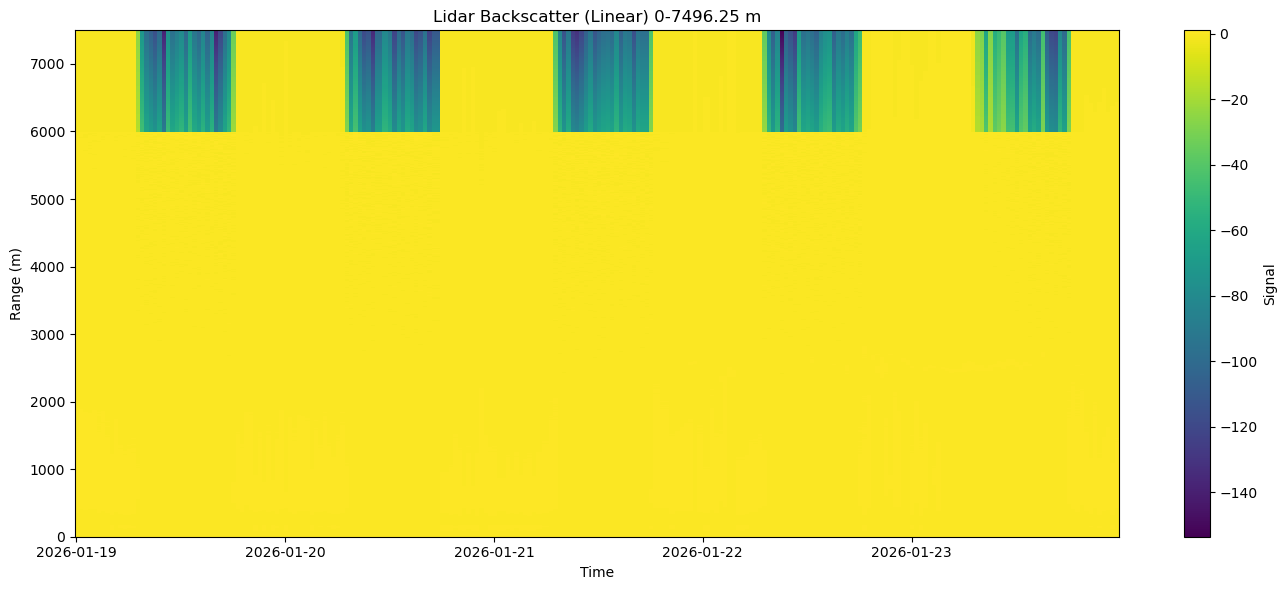

In [9]:
rmin = 0
rmax = 7496.25

Z_sel = Z.loc[(Z.index >= rmin) & (Z.index <= rmax)]

plt.figure(figsize=(14, 6))

pcm = plt.pcolormesh(
    Z_sel.columns,
    Z_sel.index,
    Z_sel.values,
    shading="auto"
)

plt.xlabel("Time")
plt.ylabel("Range (m)")
plt.title(f"Lidar Backscatter (Linear) {rmin}-{rmax} m")
plt.colorbar(pcm, label="Signal")

plt.tight_layout()
plt.show()


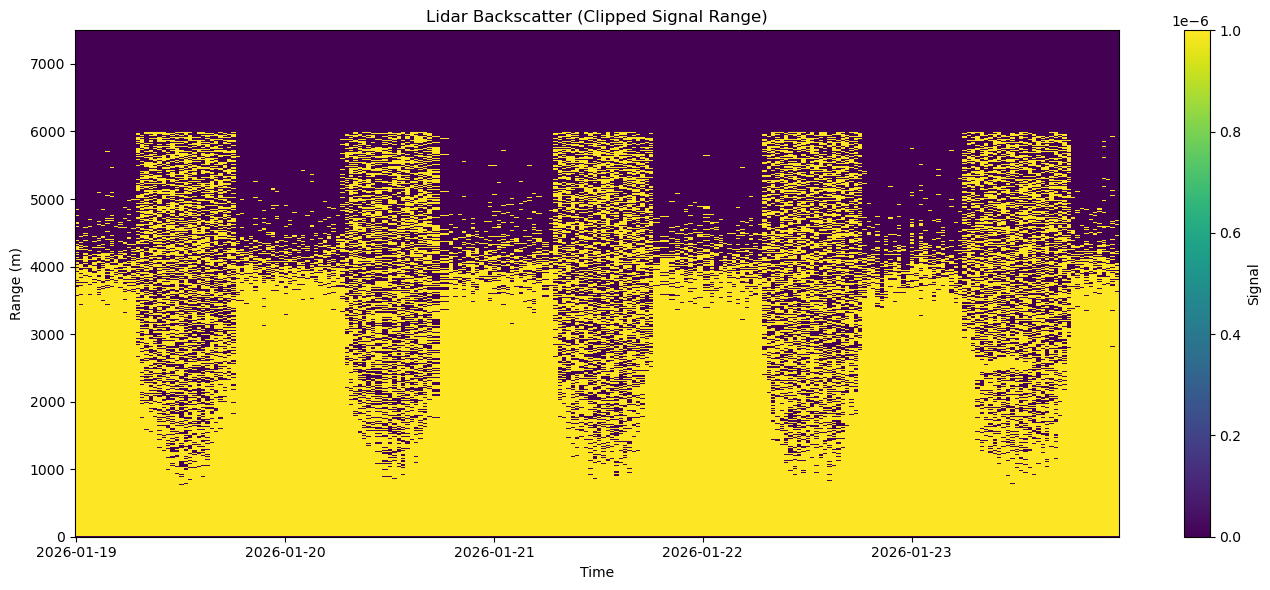

In [10]:
plt.figure(figsize=(14, 6))

pcm = plt.pcolormesh(
    Z.columns,
    Z.index,
    Z.values,
    shading="auto",
    vmin=0,
    vmax=1e-6   # choose your max signal
)

plt.colorbar(pcm, label="Signal")
plt.xlabel("Time")
plt.ylabel("Range (m)")
plt.title("Lidar Backscatter (Clipped Signal Range)")
plt.tight_layout()
plt.show()


In [11]:
path = Path("Input")

def extract_date_from_filename(fname):
    m = re.search(r"\d{2}-\d{2}-\d{4}", fname)
    if not m:
        return None
    return pd.to_datetime(m.group(), format="%d-%m-%Y")

start = pd.Timestamp("2026-01-19")
end   = pd.Timestamp("2026-01-23")

files = []
for f in path.glob("*.csv"):  # ✅ simple and reliable
    if "ALT-result-" not in f.name or "(PBL_results)" not in f.name:
        continue

    d = extract_date_from_filename(f.name)
    if d is None:
        print("Skip (no date):", f.name)
        continue

    if start <= d <= end:
        files.append((f, d))

files = sorted(files, key=lambda x: x[1])

print("Files to read:", len(files))
for f, d in files:
    print(" ", f.name, "->", d.date())

if not files:
    raise RuntimeError(f"No matching files found in {path.resolve()} for {start.date()}–{end.date()}")

dfs = []
for f, d in files:
    df = pd.read_csv(f)
    df["date"] = d
    dfs.append(df)

df_PBox = pd.concat(dfs, ignore_index=True)
df_PBox.insert(0, "date", df_PBox.pop("date"))

print("Final shape:", df_PBox.shape)
print("Dates loaded:", sorted(pd.to_datetime(df_PBox["date"]).dt.date.unique()))


Files to read: 5
  ALT-result-19-01-2026(PBL_results).csv -> 2026-01-19
  ALT-result-20-01-2026(PBL_results).csv -> 2026-01-20
  ALT-result-21-01-2026(PBL_results).csv -> 2026-01-21
  ALT-result-22-01-2026(PBL_results).csv -> 2026-01-22
  ALT-result-23-01-2026(PBL_results).csv -> 2026-01-23
Final shape: (240, 16)
Dates loaded: [datetime.date(2026, 1, 19), datetime.date(2026, 1, 20), datetime.date(2026, 1, 21), datetime.date(2026, 1, 22), datetime.date(2026, 1, 23)]


In [12]:
df_PBox["PBL_neg_m"]

0      1901.25
1      1893.75
2      1848.75
3      1830.00
4      1875.00
        ...   
235    2377.50
236    1518.75
237    1601.25
238    1365.00
239    1353.75
Name: PBL_neg_m, Length: 240, dtype: float64

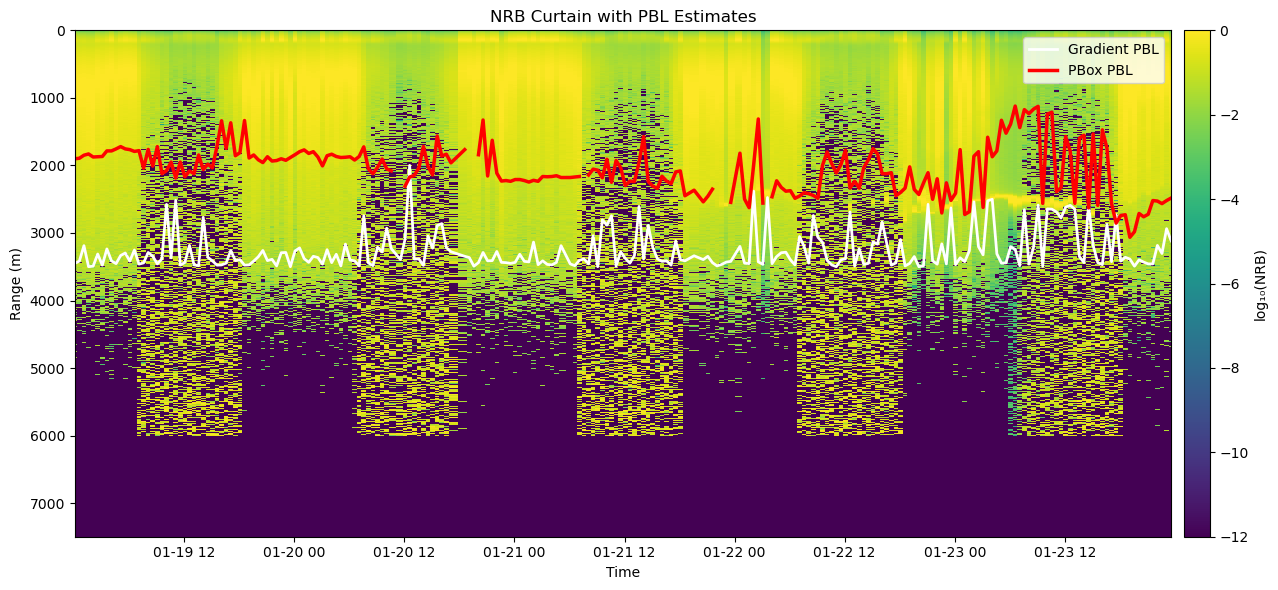

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
# INPUTS expected:
#   Z      : DataFrame, index=range_m, columns=time (datetime-like), values=NRB
#   pbl_df : DataFrame with column "pbl_m" (same order as Z.columns OR has datetime)
#   df_PBox: DataFrame with column "PBL_neg_m" (NO datetime required)
# ============================================================

# --- 1) log curtain (safe clip to avoid log<=0) ---
Z_log = np.log10(Z.clip(lower=1e-12))

# --- 2) x axis is ALWAYS Z.columns (time coordinate for everything) ---
x_time = pd.to_datetime(Z.columns)

# --- 3) y axis is range grid ---
y_range = Z.index.values

# --- 4) prepare Gradient PBL series (align to x_time) ---
if "datetime" in pbl_df.columns:
    tmp = pd.DataFrame({"datetime": x_time}).merge(
        pbl_df[["datetime", "pbl_m"]],
        on="datetime",
        how="left"
    )
    pbl_grad = tmp["pbl_m"].to_numpy(dtype=float)
else:
    pbl_grad = np.asarray(pbl_df["pbl_m"].values, dtype=float)
    n = min(len(pbl_grad), len(x_time))
    pbl_grad = pbl_grad[:n]

# --- 5) PBox PBL (assume same order as Z.columns) ---
pbl_neg = np.asarray(df_PBox["PBL_neg_m"].values, dtype=float)
n2 = min(len(pbl_neg), len(x_time))
pbl_neg = pbl_neg[:n2]
x_time2 = x_time[:n2]

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")
ax.set_facecolor("white")

# curtain
pcm = ax.pcolormesh(
    x_time,
    y_range,
    Z_log.values,
    shading="auto",
    cmap="viridis"
)

# invert y like lidar range plots (0 at top)
ax.invert_yaxis()

# Gradient PBL (white line)
ax.plot(
    x_time[:len(pbl_grad)],
    pbl_grad,
    color="white",
    linewidth=2,
    label="Gradient PBL"
)

# PBox PBL (red line)
ax.plot(
    x_time2,
    pbl_neg,
    color="red",
    linewidth=2.5,
    label="PBox PBL"
)

# lock axes
ax.set_xlim(x_time.min(), x_time.max())
ax.set_ylim(y_range.max(), y_range.min())  # inverted

ax.set_xlabel("Time")
ax.set_ylabel("Range (m)")
ax.set_title("NRB Curtain with PBL Estimates")

# colorbar ONLY for NRB
cbar1 = fig.colorbar(pcm, ax=ax, pad=0.01)
cbar1.set_label("log₁₀(NRB)")

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


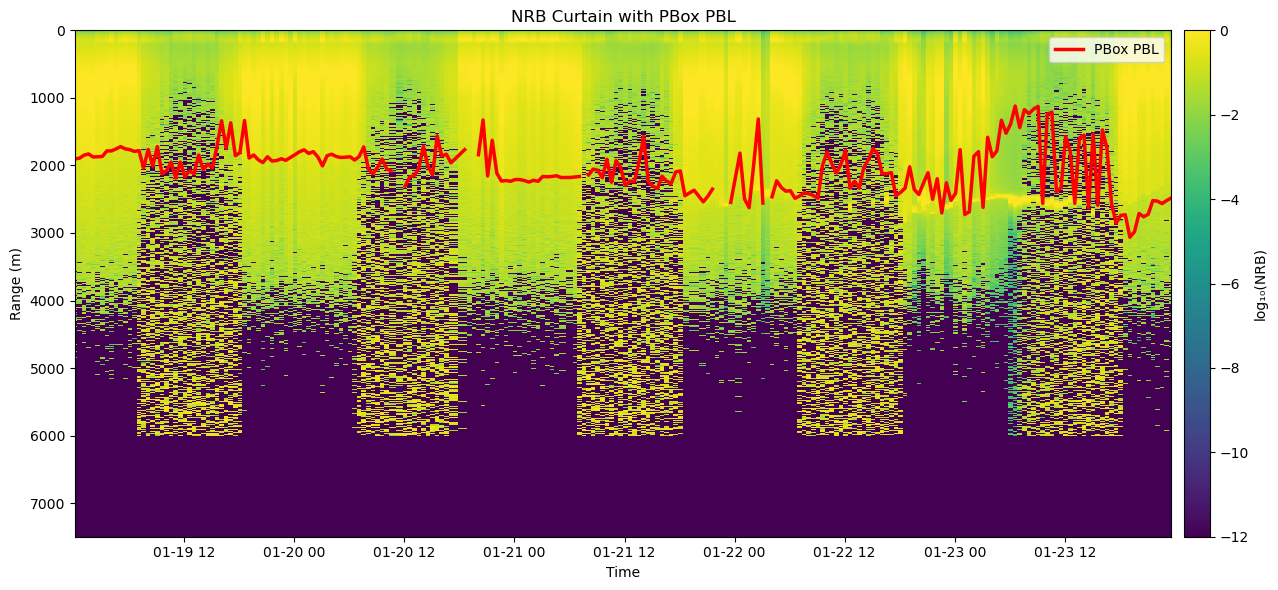

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# INPUTS expected:
#   Z      : DataFrame, index=range_m, columns=time (datetime-like), values=NRB
#   df_PBox: DataFrame with column "PBL_neg_m"
# ============================================================

# --- 1) log curtain (safe clip to avoid log<=0) ---
Z_log = np.log10(Z.clip(lower=1e-12))

# --- 2) axes ---
x_time = pd.to_datetime(Z.columns)
y_range = Z.index.values

# --- 3) PBox PBL (assume same order as Z.columns) ---
pbl_neg = np.asarray(df_PBox["PBL_neg_m"].values, dtype=float)
n = min(len(pbl_neg), len(x_time))
pbl_neg = pbl_neg[:n]
x_time2 = x_time[:n]

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")
ax.set_facecolor("white")

# NRB curtain
pcm = ax.pcolormesh(
    x_time,
    y_range,
    Z_log.values,
    shading="auto",
    cmap="viridis"
)

# invert y (lidar convention)
ax.invert_yaxis()

# PBox PBL (red line only)
ax.plot(
    x_time2,
    pbl_neg,
    color="red",
    linewidth=2.5,
    label="PBox PBL"
)

# lock axes
ax.set_xlim(x_time.min(), x_time.max())
ax.set_ylim(y_range.max(), y_range.min())

ax.set_xlabel("Time")
ax.set_ylabel("Range (m)")
ax.set_title("NRB Curtain with PBox PBL")

# only NRB colorbar
cbar = fig.colorbar(pcm, ax=ax, pad=0.01)
cbar.set_label("log₁₀(NRB)")

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
